# Import data

In [1]:
import cv2
import matplotlib.pyplot as plt

def imshow(filename):
  image = cv2.imread(filename)

  plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
  plt.axis('off')
  plt.show()
  print(image.shape)

In [2]:
path = 'D:/programing/Final Project/Alzheimer/dataset/Dataset/'

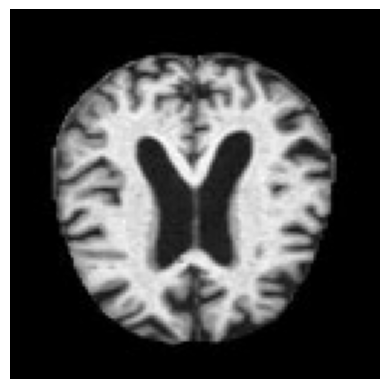

(128, 128, 3)


In [3]:
imshow(path+'Mild_Demented/mild.jpg')

# Image Preprocessing

In [4]:
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
from PIL import Image
import numpy as np
import random
random.seed(0)
torch.manual_seed(0)
np.random.seed(0)
torchvision.disable_beta_transforms_warning()

## CustomDataset to import dataset

In [5]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os
import copy
import random

class CustomDataset(Dataset):
    def __init__(self, root_dir, total_sample = 1000, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.total_sample = total_sample
        self.classes = os.listdir(root_dir)
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}
        self.images = self._get_images()
        self.class_count = self._get_class_count()
        self.images_splited_each_class = self._split_img_each_class()
        self.random_dataset = self.random_data()

    def _get_images(self):
        images = []
        for cls in self.classes:
            class_path = os.path.join(self.root_dir, cls)
            class_idx = self.class_to_idx[cls]
            for img_name in os.listdir(class_path):
                img_path = os.path.join(class_path, img_name)
                images.append((img_path, class_idx))
        return images
    
    def _get_class_count(self):
        class_count = {}
        for cls_name in self.class_to_idx.values():
            class_count[cls_name] = 0
        for key,value in self.images:
           class_count[value] += 1 
        return class_count
    
    def __len__(self):
        return len(self.random_dataset)
       
    def _get_labels(self):
        return [i[1] for i in self.images]
    
    def _split_img_each_class(self):
        data_class_split = {}
        for i in self.class_to_idx.values():
            data_class_split[i] = []
        for i in self.class_to_idx.values():
            for j in range(len(self.images)):
                if self.images[j][-1] == i:
                    data_class_split[i].append(self.images[j])
        return data_class_split
    
    def random_data(self):
        images_splited_each_class = copy.deepcopy(self.images_splited_each_class)
        random_list_idx = ['unknown'] + [i for i in range(len(self.classes))]
        allrandom_data = []

        for i in range(self.total_sample):
            random_data = []
            for class_idx in random_list_idx:
                if class_idx == 'unknown':
                    #unknown class
                    randclass = torch.randint(low=0, high=len(self.classes), size=(1,)).item()
                    random_img_unk = random.choice(images_splited_each_class[randclass])
                    random_data.append(random_img_unk)
                else:
                    #other class
                    random_img = random.choice(images_splited_each_class[class_idx])
                    random_data.append(random_img)
            allrandom_data.append(random_data)
        return allrandom_data

    def __getitem__(self, idx):
        data = self.random_dataset[idx]
        allrandom_img = []
        allrandom_label = []

        for img_path, label in data:
            img = Image.open(img_path).convert('RGB')
            if self.transform:
                img = self.transform(img)
            allrandom_img.append(img)
            allrandom_label.append(label)

        return allrandom_img, allrandom_label

In [6]:
sample_data = CustomDataset(root_dir='D:/programing/Final Project/Alzheimer/dataset/Dataset')

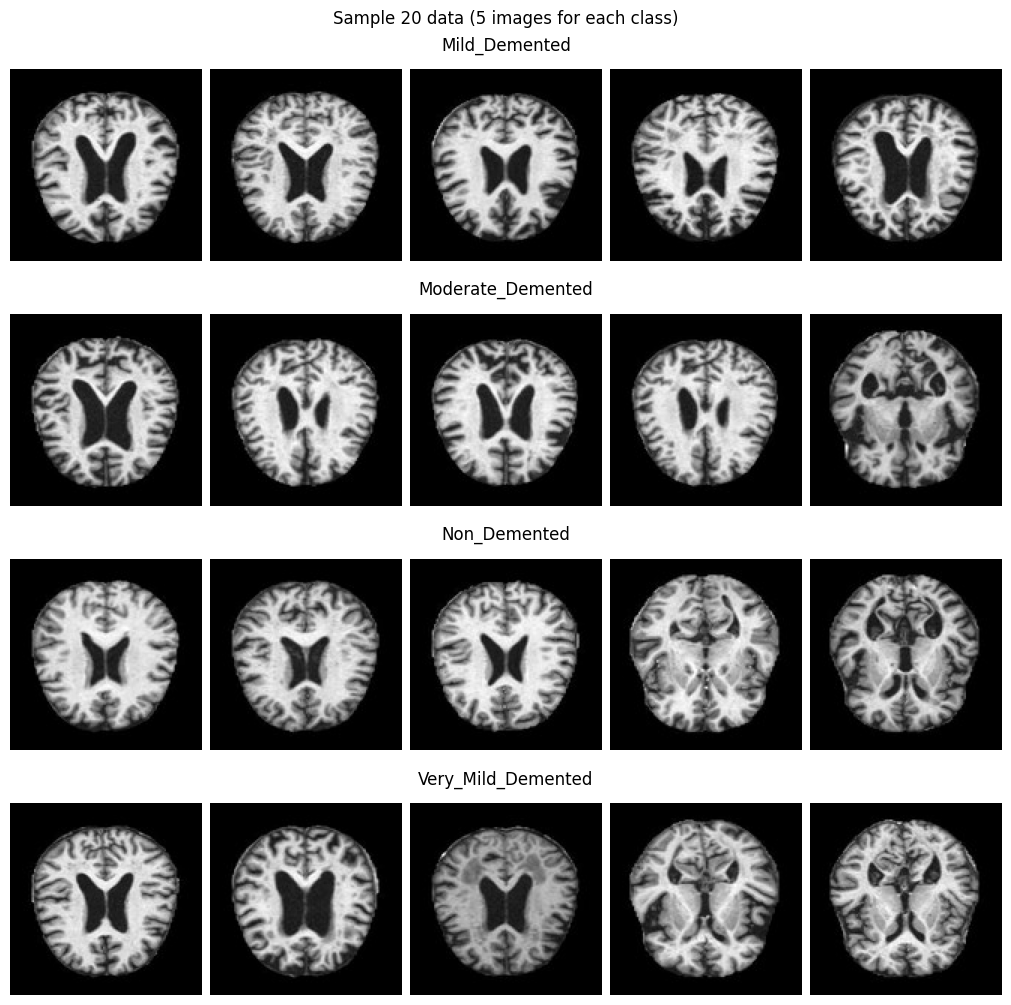

In [7]:
import matplotlib.image as mpimg
import copy

sample_data_dict = copy.deepcopy(sample_data.images_splited_each_class)

# create 4x1 subplots
fig, axs = plt.subplots(nrows=4, ncols=1, constrained_layout=True, figsize=(10, 10))
fig.suptitle('Sample 20 data (5 images for each class)')

# clear subplots
for ax in axs:
    ax.remove()

# add subfigure per subplot
gridspec = axs[0].get_subplotspec().get_gridspec()
subfigs = [fig.add_subfigure(gs) for gs in gridspec]

for row, subfig in enumerate(zip(subfigs,sample_data.classes)):
    subfig[0].suptitle(subfig[-1])

    # create 1x5 subplots per subfig
    axs = subfig[0].subplots(nrows=1, ncols=5)

    for class_label, images in sample_data_dict.items():
        for i in range(5):
            img = mpimg.imread(images[i][0])
            axs[i].imshow(img,cmap='gray')
            axs[i].axis('off')
        break
 
    del sample_data_dict[class_label]

plt.show()

## Split white and gray matter

In [8]:
class split_white_and_gray():
    def __init__(self,threshold=120) -> None:
        self.threshold = threshold

    def __call__(self,tensor):
        tensor = (tensor*255).to(torch.int64)

        # Apply thresholding
        gray_matter = torch.where(tensor >= self.threshold,tensor,0)
        gray_matter = (gray_matter/255).to(torch.float64)
        white_matter = torch.where(tensor < self.threshold,tensor,0)
        white_matter = (white_matter/255).to(torch.float64)
        tensor = (tensor/255).to(torch.float64)

        return torch.cat((gray_matter, white_matter,tensor), dim=0)

# Prepare Dataset 

## Data transforms

In [9]:
transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    split_white_and_gray(120),
])

In [10]:
Dataset = CustomDataset(root_dir='D:/programing/Final Project/Alzheimer/dataset/Dataset', transform=transform, total_sample=100)

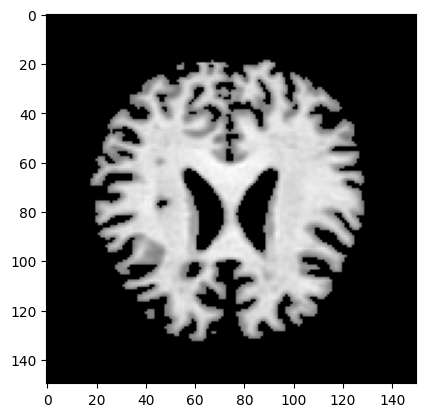

In [11]:
plt.imshow(transforms.ToPILImage()(Dataset[0][0][0][0]),cmap='gray')
plt.show()

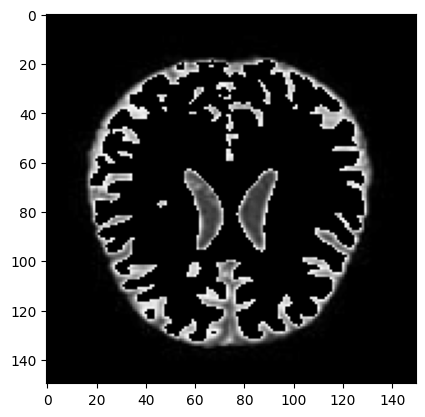

In [12]:
plt.imshow(transforms.ToPILImage()(Dataset[0][0][0][1]),cmap='gray')
plt.show()

## Split dataset 

In [13]:
from torch.utils.data import random_split

# Assuming you have a dataset named 'dataset' and it contains your data
dataset_size = len(Dataset)
train_size = int(0.4 * dataset_size)
val_size = int(0.4 * dataset_size)
test_size = dataset_size - train_size - val_size  # Remaining 20% for testing

# Split the dataset into training, validation, and test sets
train_dataset, val_test_dataset = random_split(Dataset, [train_size, val_size + test_size])
val_dataset, test_dataset = random_split(val_test_dataset, [val_size, test_size])


## Apply DataLoader

In [14]:
batch_size=64

train_dataloader = DataLoader(train_dataset, batch_size=batch_size)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size)


In [15]:
class_counts = {label: 0 for label in range(len(Dataset.classes))}

# Iterate through the DataLoader
for _, labels in train_dataloader:
    for label in labels[0]:
        class_counts[label.item()] += 1

# Print the counts
for label, count in class_counts.items():
    print(f"Class {label}: {count} items")

Class 0: 12 items
Class 1: 10 items
Class 2: 11 items
Class 3: 7 items


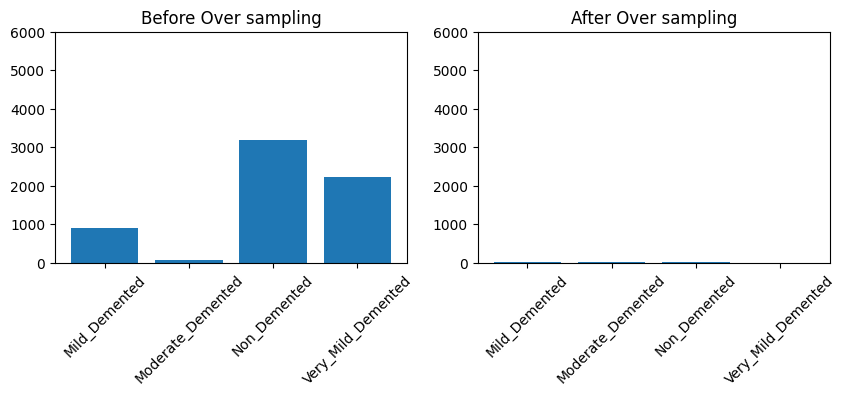

In [16]:
# Create a figure with 1 row and 2 columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))  # Adjust the figsize as needed

# Add the first subplot
ax1.bar(Dataset.classes, Dataset.class_count.values())
ax1.set_xticks(range(len(Dataset.classes)))
ax1.set_xticklabels(Dataset.classes, rotation=45)
ax1.set_ylim(top=6000)
ax1.set_title("Before Over sampling")

# Add the second subplot
ax2.bar(Dataset.classes, class_counts.values())
ax2.set_xticks(range(len(Dataset.classes)))
ax2.set_xticklabels(Dataset.classes, rotation=45)
ax2.set_ylim(top=6000)
ax2.set_title("After Over sampling")

plt.show()


## visualization of each class

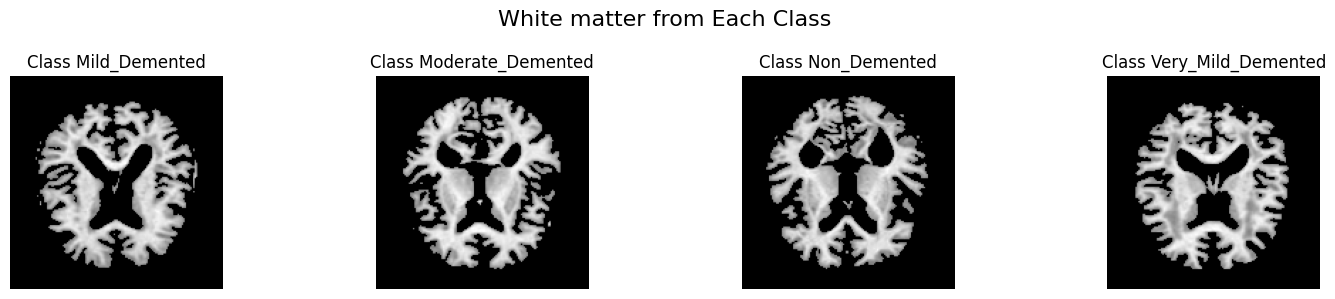

In [17]:
images, labels = next(iter(train_dataloader))

img_index = []
for label in labels[0].unique():
    img_index.append(list(labels[0]).index(label))

image_each_classes = []
for idx in img_index:
    image_each_classes.append(images[0][idx])

# Plot one image from each class
fig, axs = plt.subplots(1, len(Dataset.classes), figsize=(15, 3))
fig.suptitle("White matter from Each Class", fontsize=16)

for class_num, i in enumerate(zip(Dataset.classes,image_each_classes)):
    axs[class_num].imshow(transforms.ToPILImage()(i[-1][0]),cmap='gray')
    axs[class_num].set_title(f"Class {i[0]}")
    axs[class_num].axis('off')

plt.tight_layout()
plt.show()

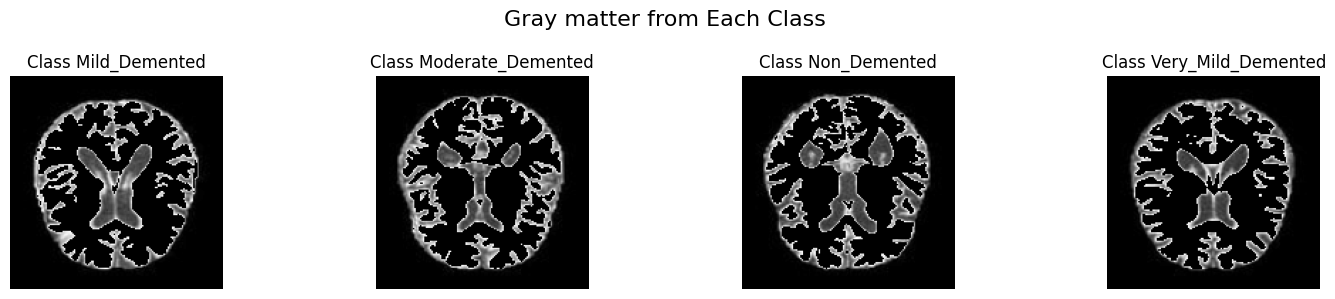

In [18]:
# Plot one image from each class
fig, axs = plt.subplots(1, len(Dataset.classes), figsize=(15, 3))
fig.suptitle("Gray matter from Each Class", fontsize=16)

for class_num, i in enumerate(zip(Dataset.classes,image_each_classes)):
    axs[class_num].imshow(transforms.ToPILImage()(i[-1][1]),cmap='gray')
    axs[class_num].set_title(f"Class {i[0]}")
    axs[class_num].axis('off')

plt.tight_layout()
plt.show()

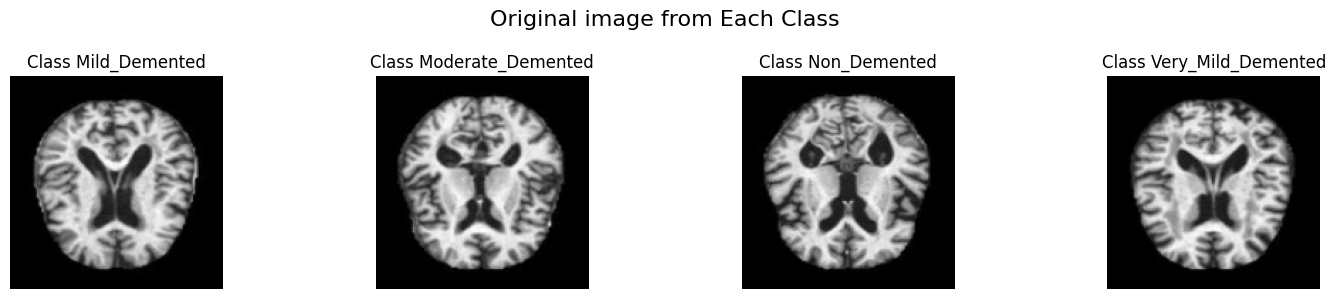

In [19]:
# Plot one image from each class
fig, axs = plt.subplots(1, len(Dataset.classes), figsize=(15, 3))
fig.suptitle("Original image from Each Class", fontsize=16)

for class_num, i in enumerate(zip(Dataset.classes,image_each_classes)):
    axs[class_num].imshow(transforms.ToPILImage()(i[-1][2]),cmap='gray')
    axs[class_num].set_title(f"Class {i[0]}")
    axs[class_num].axis('off')

plt.tight_layout()
plt.show()

# Backbone FeatureExtractor

class names : https://raw.githubusercontent.com/anishathalye/imagenet-simple-labels/master/imagenet-simple-labels.json,
https://github.com/anishathalye/imagenet-simple-labels/blob/master/imagenet-simple-labels.json

In [20]:
import requests

# Fetch the ImageNet class labels
LABELS_URL = 'https://raw.githubusercontent.com/anishathalye/imagenet-simple-labels/master/imagenet-simple-labels.json'
response = requests.get(LABELS_URL)
labels = response.json()

labels[:10]

['tench',
 'goldfish',
 'great white shark',
 'tiger shark',
 'hammerhead shark',
 'electric ray',
 'stingray',
 'cock',
 'hen',
 'ostrich']

## Resnet18 transfer model

### Cos similarity

In [21]:
import torch
import torch.nn.functional as F

# Assuming input_batch and ground_truth_batch are your tensors
input_batch = torch.randn(64, 3, 150, 150)
ground_truth_batch = torch.randn(4, 3, 150, 150)

# Reshape input_batch for cosine similarity calculation
input_batch_reshaped = input_batch.view(64, -1)  # 64 images in batch, flattened

# Reshape ground_truth_batch for cosine similarity calculation
ground_truth_batch_reshaped = ground_truth_batch.view(4, -1)  # 4 representative images per class, flattened

# Calculate cosine similarity
cosine_sim = F.cosine_similarity(input_batch_reshaped.unsqueeze(1), ground_truth_batch_reshaped.unsqueeze(0), dim=2)

# Result: cosine_sim is a tensor of size (64, 4), containing cosine similarity values for each pair of images

### Siamese Network

In [22]:
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import collections

class SiameseNetwork_Resnet18(nn.Module):
    def __init__(self):
        super(SiameseNetwork_Resnet18, self).__init__()
        self.resnet18 = models.resnet18()
        self.resnet18_removelast = nn.Sequential(*list(self.resnet18.children())[:-1])
        self.classification_head = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
        )
        self.resnet18_backbone = nn.Sequential(
            collections.OrderedDict(
                [
                    ("resnet18", self.resnet18_removelast),
                    ("Flatten", nn.Flatten()),  # Flatten the output
                    ("BatchNorm", nn.BatchNorm1d(512)),  # Batch normalization
                    ("Head", self.classification_head),
                ]
            )
        )

    def forward_once(self, x):
        return self.resnet18_backbone(x)

    #not use
    def zero_allmin(self, x):
        y = x.clone()
        y[x == x.min(dim=1, keepdims=True).values] = 0.0
        return y
    
    def softmax_with_dropout(self, logits, dropout_percentage=0.2):
        logits = logits.clone()

        # Calculate the number of values to drop
        num_values_to_drop = int(round(dropout_percentage * 4))

        # Get the indices of the lowest values
        logits[logits == torch.topk(logits, num_values_to_drop, largest=False).values] = float('-inf')

        # Apply softmax
        softmax_output = F.softmax(logits, dim=1)

        return softmax_output

    def forward(self, unknown_input, *inputs):
        # Calculate cosine similarity matrix
        outputs = torch.stack([self.forward_once(inp) for inp in inputs], dim=1)
        similarities = F.cosine_similarity(
            self.resnet18_backbone(unknown_input)[:, None, :], outputs, dim=2
        )
        
        probability = self.softmax_with_dropout(similarities)

        return probability


In [23]:
# Move the model to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
snr = SiameseNetwork_Resnet18().float().to(device)

In [24]:
snr.eval()
a = next(iter(train_dataloader))[0]
i = [i.to(torch.float) for i in a]
snr(*i)

tensor([[0.0000, 0.3331, 0.3335, 0.3334],
        [0.3334, 0.3332, 0.3334, 0.0000],
        [0.3335, 0.3334, 0.0000, 0.3331],
        [0.3332, 0.3335, 0.0000, 0.3333],
        [0.3334, 0.3333, 0.3333, 0.0000],
        [0.3333, 0.3333, 0.3334, 0.0000],
        [0.0000, 0.3334, 0.3332, 0.3334],
        [0.3334, 0.3334, 0.3332, 0.0000],
        [0.3335, 0.3333, 0.3333, 0.0000],
        [0.0000, 0.3334, 0.3332, 0.3333],
        [0.3333, 0.3335, 0.3332, 0.0000],
        [0.3330, 0.3334, 0.3336, 0.0000],
        [0.0000, 0.3333, 0.3334, 0.3332],
        [0.0000, 0.3334, 0.3334, 0.3333],
        [0.3333, 0.3332, 0.0000, 0.3335],
        [0.3334, 0.3333, 0.3333, 0.0000],
        [0.0000, 0.3334, 0.3334, 0.3332],
        [0.3335, 0.0000, 0.3330, 0.3335],
        [0.0000, 0.3336, 0.3331, 0.3333],
        [0.3332, 0.0000, 0.3333, 0.3335],
        [0.3332, 0.3335, 0.3333, 0.0000],
        [0.0000, 0.3334, 0.3332, 0.3334],
        [0.3331, 0.3335, 0.0000, 0.3334],
        [0.3333, 0.3335, 0.3332, 0

### Layers and Params

In [25]:
# Print parameters for each layer
for name, param in snr.named_parameters():
    print(f"Layer: {name}, Size: {param.size()}, Parameters: {param.numel()}")

Layer: resnet18.conv1.weight, Size: torch.Size([64, 3, 7, 7]), Parameters: 9408
Layer: resnet18.bn1.weight, Size: torch.Size([64]), Parameters: 64
Layer: resnet18.bn1.bias, Size: torch.Size([64]), Parameters: 64
Layer: resnet18.layer1.0.conv1.weight, Size: torch.Size([64, 64, 3, 3]), Parameters: 36864
Layer: resnet18.layer1.0.bn1.weight, Size: torch.Size([64]), Parameters: 64
Layer: resnet18.layer1.0.bn1.bias, Size: torch.Size([64]), Parameters: 64
Layer: resnet18.layer1.0.conv2.weight, Size: torch.Size([64, 64, 3, 3]), Parameters: 36864
Layer: resnet18.layer1.0.bn2.weight, Size: torch.Size([64]), Parameters: 64
Layer: resnet18.layer1.0.bn2.bias, Size: torch.Size([64]), Parameters: 64
Layer: resnet18.layer1.1.conv1.weight, Size: torch.Size([64, 64, 3, 3]), Parameters: 36864
Layer: resnet18.layer1.1.bn1.weight, Size: torch.Size([64]), Parameters: 64
Layer: resnet18.layer1.1.bn1.bias, Size: torch.Size([64]), Parameters: 64
Layer: resnet18.layer1.1.conv2.weight, Size: torch.Size([64, 64, 

In [26]:
sum(p.numel() for p in snr.parameters())

11854760

### Draw graph

In [27]:
# from torchviz import make_dot

# # Generate a visual representation of the model's computational graph
# y = snr(i1,i2,i3,i4,i5)
# dot = make_dot(y, params=dict(snr.named_parameters()))

# # Save the generated graph as an image
# dot.render("your_model_graph")

### training

In [28]:
from torch.optim import lr_scheduler
import tqdm.notebook as tq
import torch.optim as optim
from sklearn.metrics import accuracy_score

# training
# Loop for training
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(snr.parameters(), lr=0.001)
scheduler = lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

num_epochs = 5
train_loss_history = []
train_accuracy_history = []
validation_loss_history = []
validation_accuracy_history = []

for epoch in tq.tqdm(range(num_epochs), desc="Epoch num", position=0, leave=True):
    # Switch between training and evaluation modes
    running_loss = 0.0
    all_labels = []
    all_predictions = []

    val_running_loss = 0.0
    val_all_labels = []
    val_all_predictions = []

    # Use DataLoader directly for batching
    for train_set, val_set in zip(train_dataloader, val_dataloader):
        inputs, labels = train_set
        val_inputs, val_labels = val_set

        snr.train()
        optimizer.zero_grad()

        # Move inputs and labels to device
        inputs = [inp.to(torch.float32).to(device) for inp in inputs]
        outputs = snr(*inputs)
        loss = criterion(outputs, labels[0])
        
        if snr.training:
            loss.backward()
            optimizer.step()

        # Track predictions for accuracy calculation
        _, predictions = torch.max(outputs, 1)
        all_labels.extend(labels[0].to(device).numpy())
        all_predictions.extend(predictions.cpu().numpy())

        # Accumulate the loss
        running_loss += loss.item()

        # Validation set
        snr.eval()
        with torch.no_grad():
            val_inputs = [inp.to(torch.float32).to(device) for inp in val_inputs]
            val_outputs = snr(*val_inputs)
            val_loss = criterion(val_outputs, val_labels[0])

            _, val_predictions = torch.max(val_outputs, 1)
            val_all_labels.extend(val_labels[0].to(device).numpy())
            val_all_predictions.extend(val_predictions.cpu().numpy())

            val_running_loss += val_loss.item()

    scheduler.step()

    # Calculate accuracy on training set
    accuracy = accuracy_score(all_labels, all_predictions)
    average_train_loss = running_loss / len(train_dataloader)
    train_loss_history.append(average_train_loss)
    train_accuracy_history.append(accuracy)

    # Calculate accuracy on validation set
    val_accuracy = accuracy_score(val_all_labels, val_all_predictions)
    average_validation_loss = val_running_loss / len(val_dataloader)
    validation_loss_history.append(average_validation_loss)
    validation_accuracy_history.append(val_accuracy)
                                       
    # Print statistics for the epoch
    print("-------------------------------------------------------------------")
    print(f"Epoch {epoch + 1}/{num_epochs}")
    print(f"Training Loss   : {average_train_loss:.3f}  |  Training Accuracy   : {accuracy:.3f}")
    print(f"Validation Loss : {average_validation_loss:.3f}  |  Validation Accuracy : {val_accuracy:.3f}")
    print("-------------------------------------------------------------------")
    print()

Epoch num:   0%|          | 0/5 [00:00<?, ?it/s]

-------------------------------------------------------------------
Epoch 1/5
Training Loss   : 1.421  |  Training Accuracy   : 0.275
Validation Loss : 1.388  |  Validation Accuracy : 0.450
-------------------------------------------------------------------

-------------------------------------------------------------------
Epoch 2/5
Training Loss   : 1.310  |  Training Accuracy   : 0.600
Validation Loss : 1.388  |  Validation Accuracy : 0.250
-------------------------------------------------------------------

-------------------------------------------------------------------
Epoch 3/5
Training Loss   : 1.263  |  Training Accuracy   : 0.925
Validation Loss : 1.404  |  Validation Accuracy : 0.275
-------------------------------------------------------------------

-------------------------------------------------------------------
Epoch 4/5
Training Loss   : 1.188  |  Training Accuracy   : 0.950
Validation Loss : 1.413  |  Validation Accuracy : 0.325
---------------------------------

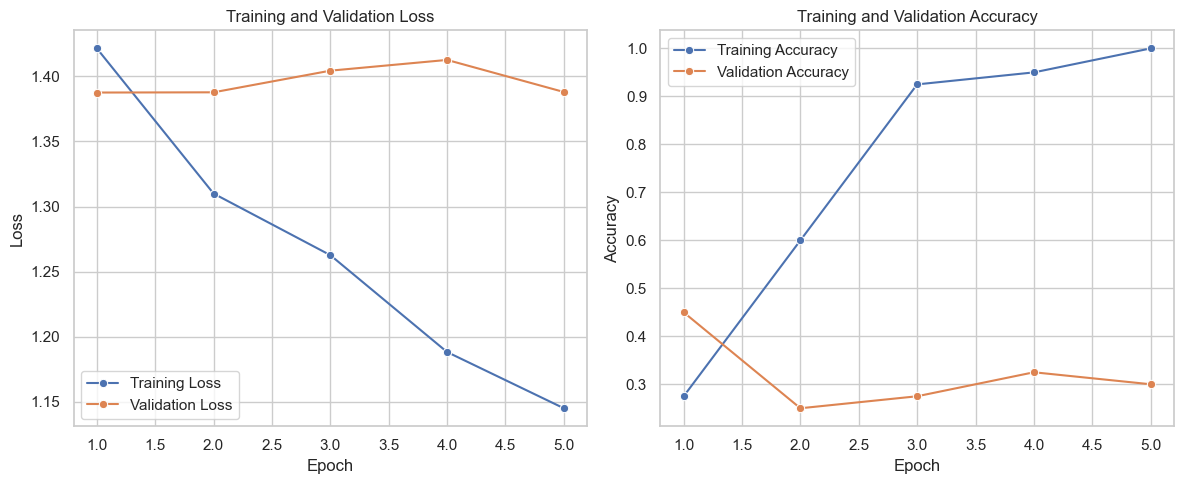

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the seaborn style
sns.set(style="whitegrid")

# Create two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plotting the Loss
sns.lineplot(x=range(1, len(train_loss_history) + 1), y=train_loss_history, label='Training Loss', marker='o', ax=axes[0])
sns.lineplot(x=range(1, len(validation_loss_history) + 1), y=validation_loss_history, label='Validation Loss', marker='o', ax=axes[0])
axes[0].set_title('Training and Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Plotting the Accuracy
sns.lineplot(x=range(1, len(train_accuracy_history) + 1), y=train_accuracy_history, label='Training Accuracy', marker='o', ax=axes[1])
sns.lineplot(x=range(1, len(validation_accuracy_history) + 1), y=validation_accuracy_history, label='Validation Accuracy', marker='o', ax=axes[1])
axes[1].set_title('Training and Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()


In [30]:
import torch
import psutil

# After training
current_process = psutil.Process()
memory_info = current_process.memory_info()

print(f"Memory used during training: {memory_info.rss / 1024**2} MB")


Memory used during training: 3062.13671875 MB


### Save model

In [31]:
#torch.save(resnet18_backbone, "resnet18_backbone.pth")

In [32]:
#loaded_model = torch.load("resnet18_backbone.pth")

## CONVNEXT_BASE

In [33]:
# Load pre-trained convnext_base model
convnext_base = models.convnext_base(weights=models.ConvNeXt_Base_Weights.DEFAULT)

modules_except_last = list(convnext_base.children())[:-1]
last_module = list(convnext_base.children())[-1]
modified_last_module = nn.Sequential(*list(last_module.children())[:-1])

convnext_base_removelast = nn.Sequential(*modules_except_last, modified_last_module)

# Add a new classification head for 4 classes
num_classes = 4

# Adjust the size of the new classification head based on the output size
classification_head = nn.Sequential(
    nn.Linear(1024, 512),  # Linear layer
    nn.ReLU(inplace=True),
    nn.Linear(512, 256),
    nn.ReLU(inplace=True),
    nn.Linear(256, num_classes),
    nn.Softmax(dim=1),  # Softmax activation along dimension 1 (assuming 0-indexed)
)

# Combine the feature extraction backbone and the new classification head
convnextbase_backbone = nn.Sequential(
    collections.OrderedDict(
        [
            ("convnextbase", convnext_base_removelast),
            ("Head", classification_head),
        ]
    )
)

# Move the model to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
convnextbase_backbone.to(device)

Sequential(
  (convnextbase): Sequential(
    (0): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
        (1): LayerNorm2d((128,), eps=1e-06, elementwise_affine=True)
      )
      (1): Sequential(
        (0): CNBlock(
          (block): Sequential(
            (0): Conv2d(128, 128, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=128)
            (1): Permute()
            (2): LayerNorm((128,), eps=1e-06, elementwise_affine=True)
            (3): Linear(in_features=128, out_features=512, bias=True)
            (4): GELU(approximate='none')
            (5): Linear(in_features=512, out_features=128, bias=True)
            (6): Permute()
          )
          (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        )
        (1): CNBlock(
          (block): Sequential(
            (0): Conv2d(128, 128, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=128)
            (1): Permute()
            (2): Layer

In [34]:
sum(p.numel() for p in convnextbase_backbone.parameters())

88223620